<a href="https://colab.research.google.com/github/sasafirahaja15-gif/iris_sampling_bootstrap/blob/main/TugasPraprosesing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset yang digunakan adalah dataset sumber daya manusia (SDM) sintetis yang sangat populer untuk praktik analisis data. Dataset ini mencakup berbagai dimensi informasi karyawan, mulai dari demografi, performa, hingga alasan pemberhentian.

Dataset ini berisi informasi tentang 311 karyawan dengan 36 kolom fitur. Secara garis besar, data dibagi menjadi:


*   Demografi: Nama, ID, Jenis
Kelamin, Ras, Status Pernikahan.
*   Kompensasi & Posisi: Gaji (Salary), Jabatan (Position), Departemen.
*   Performa & Keterlibatan: Skor Performa (PerfScoreID), Survei Kepuasan (EmpSatisfaction), Keterlibatan (EngagementSurvey).
*   Status Pekerjaan: Tanggal Perekrutan, Tanggal Terminasi, Alasan Berhenti, Status Aktif.

## **A. Pemanggilan Data**

Memuat Data dan Inspeksi Struktur
Langkah awal adalah memahami tipe data untuk memastikan tidak ada kolom angka yang terbaca sebagai teks atau sebaliknya.

In [ ]:
import pandas as pd

# Memuat dataset
df = pd.read_csv('HRDataset_v14.csv')

# Menampilkan informasi dasar
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

Output ini memberikan gambaran tentang jumlah baris (311) dan kolom (36). Kita dapat melihat kolom mana yang memiliki nilai null (seperti DateofTermination) dan memastikan tipe data Salary adalah numerik.

##B. Penanganan Nilai Hilang (Handling Missing Values)

Data yang hilang harus diidentifikasi apakah bersifat Missing at Random atau memiliki arti tertentu.
*   Kolom DateofTermination: Memiliki banyak nilai null karena karyawan tersebut masih aktif bekerja.
*   ManagerID: Mungkin memiliki beberapa nilai kosong yang perlu diisi atau dihapus.


In [ ]:
# Mengecek jumlah missing values
missing_data = df.isnull().sum()

# Mengisi ManagerID yang kosong dengan 0 atau nilai default
df['ManagerID'] = df['ManagerID'].fillna(0)

Kita mengamankan integritas data numerik. Kolom DateofTermination dibiarkan null karena secara konteks menunjukkan status "Masih Bekerja", namun untuk analisis durasi kerja, biasanya kita mengganti null dengan tanggal hari ini.

## C. Pembersihan Data (Data Cleaning)

Menghapus spasi berlebih pada data teks agar tidak terjadi duplikasi kategori (misal: "Production" vs "Production ").

In [ ]:
# Konversi ke datetime
df['DOB'] = pd.to_datetime(df['DOB'])
df['DateofHire'] = pd.to_datetime(df['DateofHire'])

/tmp/ipykernel_3597/1706971517.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DOB'] = pd.to_datetime(df['DOB'])


Dengan format datetime, kita bisa mengekstrak informasi baru seperti "Lama Bekerja" atau "Usia Karyawan" saat direkrut.

##D. Konversi Tipe Data (Feature Engineering)
Mengubah kolom tanggal dari objek/string menjadi format datetime agar bisa dihitung.

In [ ]:
# Contoh merubah Gender menjadi angka
df['GenderID'] = df['Sex'].map({'M': 1, 'F': 0})

Variabel kategori Sex kini diwakili oleh angka 1 dan 0, sehingga siap digunakan dalam algoritma korelasi atau regresi.

##E. Encoding Variabel Kategorikal
Model statistik memerlukan input angka. Kita mengubah data teks menjadi angka menggunakan Label Encoding atau One-Hot Encoding.

In [ ]:
# Deskripsi statistik untuk melihat outlier pada Salary
salary_desc = df['Salary'].describe()

nilai max pada Salary terpaut sangat jauh dari mean dan 75% (quartile 3), maka terdapat outlier yang mungkin perlu ditangani agar tidak membias hasil analisis rata-rata.

##F. Deteksi Outlier (Pencilan)

Menggunakan metode statistika untuk melihat apakah ada gaji yang terlalu ekstrim.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Menentukan fitur dan target
X = df[['Salary', 'EngagementSurvey', 'EmpSatisfaction', 'Absences', 'SpecialProjectsCount', 'GenderID']]
y = df['Termd']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membangun model Random Forest
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

Setelah model berjalan, kita akan mendapatkan output berupa Confusion Matrix dan Feature Importance.

/tmp/ipykernel_3597/3879273912.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Termd', y='Salary', data=df, palette='Set2')


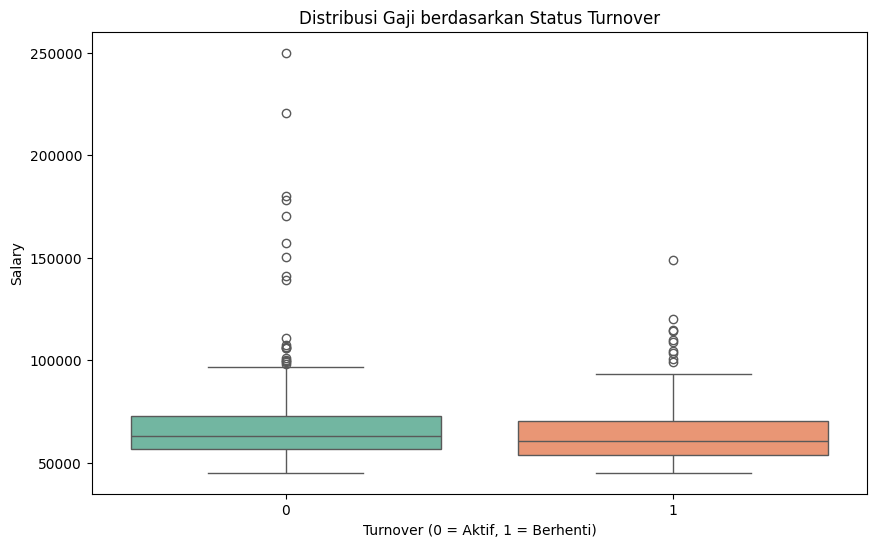

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='Termd', y='Salary', data=df, palette='Set2')
plt.title('Distribusi Gaji berdasarkan Status Turnover')
plt.xlabel('Turnover (0 = Aktif, 1 = Berhenti)')
plt.ylabel('Salary')
plt.show()

Salary vs Turnover
Median: Garis di tengah kotak
menunjukkan nilai tengah gaji. Jika median pada kategori 1 lebih rendah, ini indikasi awal bahwa gaji rendah memicu orang untuk keluar.

Rentang (Whiskers): Menunjukkan variasi gaji. Kita bisa melihat apakah ada "outlier" (titik-titik di luar garis) yang merupakan karyawan dengan gaji sangat tinggi yang tetap keluar atau bertahan.

/tmp/ipykernel_3597/3027042237.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Termd', y='EngagementSurvey', data=df, palette='viridis')


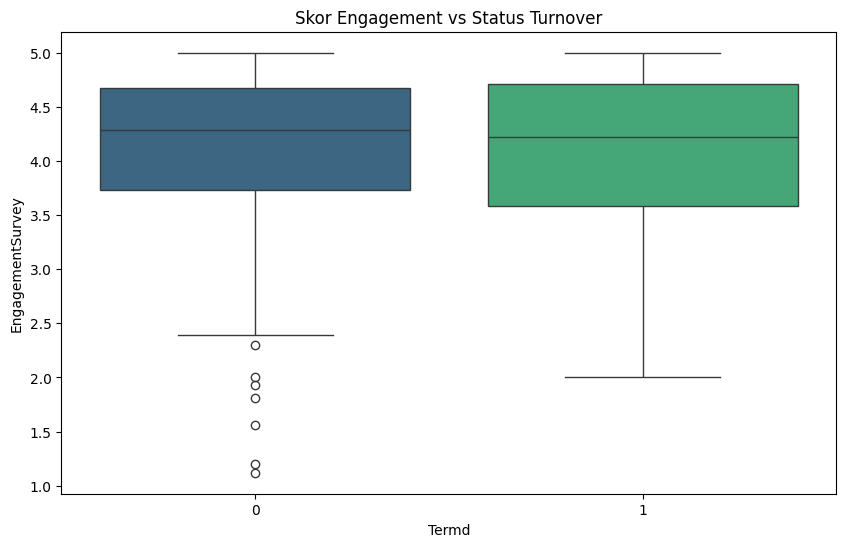

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Termd', y='EngagementSurvey', data=df, palette='viridis')
plt.title('Skor Engagement vs Status Turnover')
plt.show()

Engagement Survey vs Turnover
Jika kotak pada status 1 (Berhenti) terletak lebih rendah daripada status 0, artinya karyawan yang keluar umumnya memiliki tingkat keterlibatan yang lebih rendah sebelum mereka memutuskan pergi. Ini memperkuat model prediktif kita.

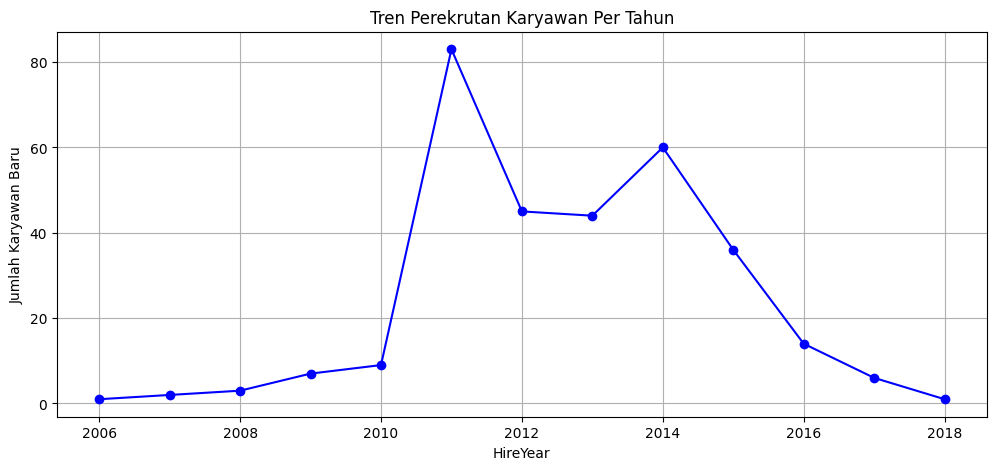

In [ ]:
# Mengelompokkan jumlah rekrutmen per tahun
df['HireYear'] = df['DateofHire'].dt.year
hire_trend = df.groupby('HireYear').size()

plt.figure(figsize=(12, 5))
hire_trend.plot(kind='line', marker='o', color='b')
plt.title('Tren Perekrutan Karyawan Per Tahun')
plt.ylabel('Jumlah Karyawan Baru')
plt.grid(True)
plt.show()

Tren Perekrutan (Time Series)
Grafik ini menunjukkan dinamika pertumbuhan perusahaan. Jika ada lonjakan rekrutmen yang sangat tajam di tahun tertentu diikuti oleh angka turnover yang tinggi, bisa jadi ada masalah dalam proses onboarding atau budaya kerja pada periode tersebut.